# Model Interpretability and Diagnostics

Accuracy alone does not explain *why* a model works or where it fails.
This notebook adds four diagnostic layers on top of the models trained in notebook 02:

1. **Learning curves** — does more data help? Are models under- or over-fitting?
2. **ROC curves + AUC** — per-class discriminative power, independent of threshold.
3. **Permutation importance** — which features actually drive predictions?
4. **Calibration curves** — do predicted probabilities match empirical frequencies?

All analysis uses the training CSV (via CV) except for the final calibration check,
which uses the held-out test CSV.

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve, auc, accuracy_score
from xgboost import XGBClassifier

from src.data import load_features, CLASSES
from src.models import AttentionClassifier, LogisticRegressionOvR, LogisticRegressionSoftmax
from src.evaluation import (make_skf, cross_validate_custom,
                             plot_learning_curves, plot_confusion_matrices)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
SKF = make_skf()

In [3]:
X_full, y_full = load_features('../data/train_energy_data.csv', 'core')
X_test, y_test = load_features('../data/test_energy_data.csv',  'core')

X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)
X_full_sc = scaler.transform(X_full)

# Fit best models (configs match notebook 02)
lr_model = LogisticRegression(C=10, solver='lbfgs', max_iter=1000)
lr_model.fit(X_train_sc, y_train)

mlp_model = MLPClassifier(hidden_layer_sizes=(20, 20), activation='relu',
                           alpha=1e-5, max_iter=3000, early_stopping=True,
                           random_state=42)
mlp_model.fit(X_train_sc, y_train)

xgb_model = XGBClassifier(objective='multi:softmax', num_class=3,
                           eval_metric='mlogloss', max_depth=3,
                           learning_rate=0.05, n_estimators=200,
                           subsample=0.8, colsample_bytree=1.0, gamma=0,
                           random_state=42, verbosity=0)
xgb_model.fit(X_train, y_train)

attn_model = AttentionClassifier(w=2.0)
attn_model.fit(X_train_sc, y_train)

softmax_model = LogisticRegressionSoftmax(eta=0.01, n_iter=1000)
softmax_model.fit(X_train_sc, y_train)

print('Models fitted.')
for name, model, X in [('LR', lr_model, X_test_sc),
                        ('MLP', mlp_model, X_test_sc),
                        ('XGBoost', xgb_model, X_test),
                        ('Attention', attn_model, X_test_sc),
                        ('Softmax LR', softmax_model, X_test_sc)]:
    print(f"  {name:<12} test acc={accuracy_score(y_test, model.predict(X)):.4f}")

Models fitted.
  LR           test acc=0.6400
  MLP          test acc=0.6000
  XGBoost      test acc=0.6500
  Attention    test acc=0.5300
  Softmax LR   test acc=0.6000


---
## 1 — Learning Curves

Learning curves plot training and CV-validation accuracy as the number of training examples grows.

- **Train > CV val by a large gap** → overfitting (more data or regularisation needed)
- **Both low** → underfitting (model too simple or features too weak)
- **Both converged at moderate n** → data saturation (more data won't help much)

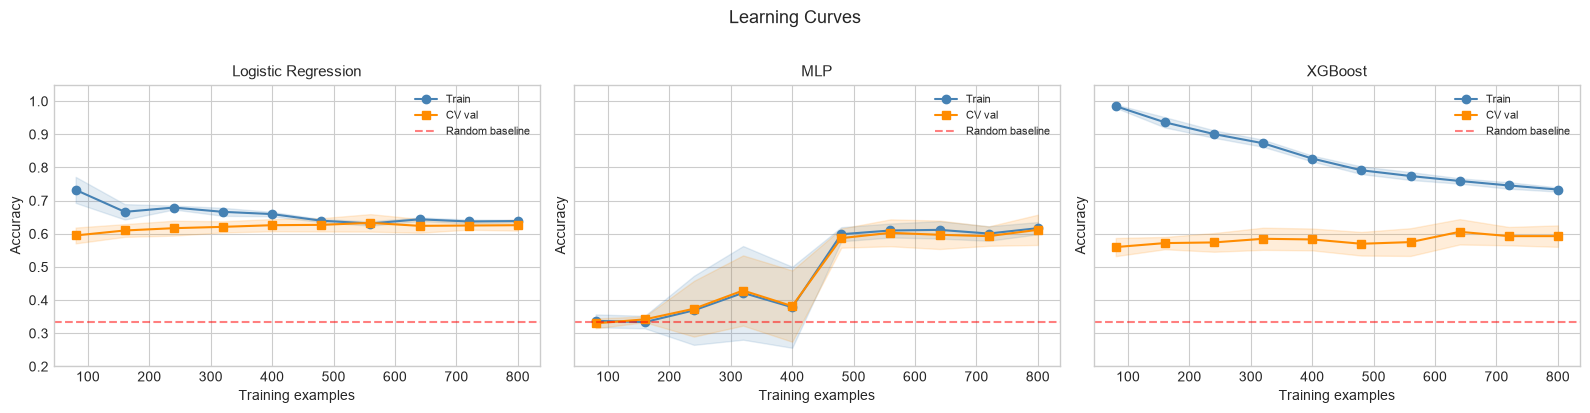

In [4]:
named_estimators = [
    ('Logistic Regression',
     make_pipeline(StandardScaler(),
                   LogisticRegression(C=10, max_iter=1000))),
    ('MLP',
     make_pipeline(StandardScaler(),
                   MLPClassifier(hidden_layer_sizes=(20, 20), activation='relu',
                                 alpha=1e-5, max_iter=3000, early_stopping=True,
                                 random_state=42))),
    ('XGBoost',
     XGBClassifier(objective='multi:softmax', num_class=3, eval_metric='mlogloss',
                   max_depth=3, learning_rate=0.05, n_estimators=200,
                   subsample=0.8, random_state=42, verbosity=0)),
]

le = LabelEncoder()
y_encoded = le.fit_transform(y_full)

fig = plot_learning_curves(named_estimators, X_full, y_encoded,
                            train_sizes=np.linspace(0.1, 1.0, 10))
plt.show()

**Observations:**  
- If train and CV curves converge early, the dataset of 800–1000 samples is sufficient and collecting more data of the same type is unlikely to help — improving features would be the better investment.  
- A persistent train/CV gap in MLP or XGBoost would indicate mild overfitting, addressable with stronger regularisation.

---
## 2 — ROC Curves and AUC (One-vs-Rest)

For each class k, we treat the problem as binary (class k vs. all others) and plot the
ROC curve using each model's `predict_proba` output.
AUC = 1.0 is perfect; AUC = 0.5 is random.  

This reveals *per-class* discrimination — e.g. a model might identify Industrial
buildings well but confuse Residential and Commercial.

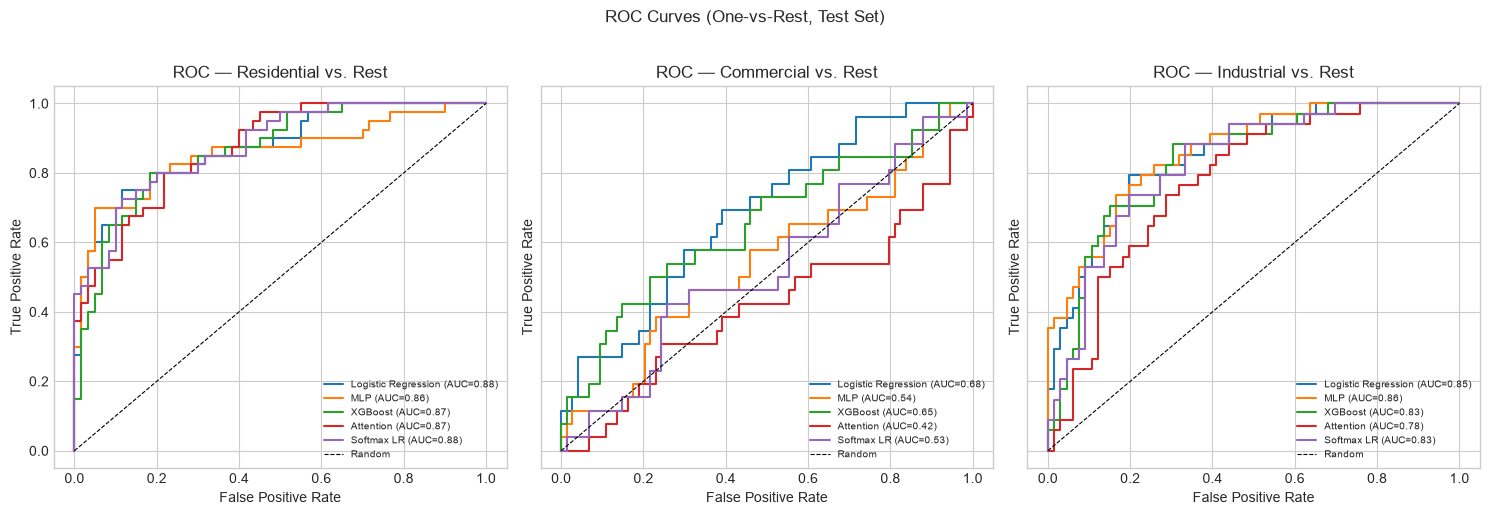

In [5]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])  # (n, 3) one-hot

roc_models = [
    ('Logistic Regression', lr_model,      X_test_sc, 'predict_proba'),
    ('MLP',                 mlp_model,     X_test_sc, 'predict_proba'),
    ('XGBoost',             xgb_model,     X_test,    'predict_proba'),
    ('Attention',           attn_model,    X_test_sc, 'predict_proba'),
    ('Softmax LR',          softmax_model, X_test_sc, 'predict_proba'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
palette = sns.color_palette('tab10', len(roc_models))

for k, class_name in enumerate(CLASSES):
    ax = axes[k]
    for (name, model, X, _), color in zip(roc_models, palette):
        proba = model.predict_proba(X)
        fpr, tpr, _ = roc_curve(y_test_bin[:, k], proba[:, k])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=1.5,
                label=f'{name} (AUC={roc_auc:.2f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC — {class_name} vs. Rest')
    ax.legend(fontsize=7, loc='lower right')

plt.suptitle('ROC Curves (One-vs-Rest, Test Set)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**Observations:**  
- Classes with AUC > 0.80 are well-separated by that model.  
- Lower AUC classes are where accuracy is lost — a targeted feature addition for those classes is more effective than adding regularisation.

---
## 2b — Threshold Tuning & Precision–Recall Curves

The default decision rule is argmax(probabilities). Sweeping the per-class threshold
trades precision for recall — critical when false positives and false negatives have
different business costs (e.g. missing an Industrial building triggers an expensive audit).

**Precision–Recall curves** are more informative than ROC when classes are imbalanced.  
**Average Precision (AP)** summarises the curve as a single number (higher = better).

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

pr_models = [
    ("Logistic Regression", lr_model,      X_test_sc),
    ("MLP",                 mlp_model,     X_test_sc),
    ("XGBoost",             xgb_model,     X_test),
    ("Attention",           attn_model,    X_test_sc),
    ("Softmax LR",          softmax_model, X_test_sc),
]

class_colors = ["#CC0000", "#006600", "#0000CC"]

fig, axes = plt.subplots(len(pr_models), 3, figsize=(13, 3 * len(pr_models)))

for row, (name, model, X_ev) in enumerate(pr_models):
    proba = model.predict_proba(X_ev)
    for col, (cls, color) in enumerate(zip(CLASSES, class_colors)):
        ax = axes[row, col]
        y_bin_col = (y_test == col).astype(int)
        prec, rec, _ = precision_recall_curve(y_bin_col, proba[:, col])
        ap = average_precision_score(y_bin_col, proba[:, col])
        ax.plot(rec, prec, color=color, lw=1.5, label=f"AP={ap:.2f}")
        ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
        ax.set_title(f"{name}
{cls}", fontsize=8)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
        ax.legend(fontsize=8)

fig.suptitle("Precision-Recall Curves (One-vs-Rest per class)", fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

In [ ]:
# Threshold sweep — XGBoost, Industrial class (index 2)
proba_xgb = xgb_model.predict_proba(X_test)
y_ind     = (y_test == 2).astype(int)
prec, rec, thresholds = precision_recall_curve(y_ind, proba_xgb[:, 2])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(thresholds, prec[:-1], "b-", label="Precision")
axes[0].plot(thresholds, rec[:-1],  "r-", label="Recall")
axes[0].axvline(0.5, color="gray", ls="--", alpha=0.6, label="Default threshold")
axes[0].set_xlabel("Decision threshold"); axes[0].set_ylabel("Score")
axes[0].set_title("XGBoost — Industrial: precision & recall vs threshold")
axes[0].legend()

sc = axes[1].scatter(rec[:-1], prec[:-1], c=thresholds, cmap="viridis", s=8)
plt.colorbar(sc, ax=axes[1], label="Threshold")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("PR curve coloured by threshold value")

plt.tight_layout(); plt.show()
print("Raise threshold → higher precision, lower recall (fewer false alarms).")
print("Lower threshold → higher recall, lower precision (catch more positives).")

**Observations:**
- High AP means the model maintains both high precision and recall across thresholds.
- The threshold sweep makes the trade-off concrete: choose the operating point that
  matches your cost function (e.g. precision ≥ 0.80 for the Industrial class).
- If classes are balanced and costs are symmetric, argmax(proba) at 0.5 is optimal.
  If one misclassification is costlier, tune the threshold on the validation set.

---
## 3 — Permutation Importance

Permutation importance measures how much test accuracy drops when a single feature column
is randomly shuffled (breaking its relationship with the target).
Unlike XGBoost's built-in split-count importance, this is model-agnostic and
measures the *actual predictive contribution* rather than usage frequency.

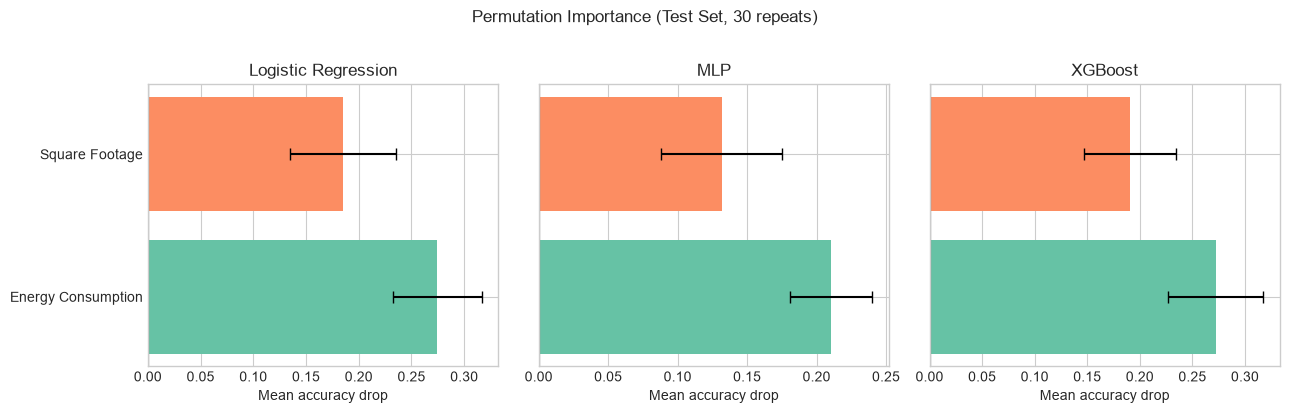

In [6]:
feature_names = ['Energy Consumption', 'Square Footage']

perm_models = [
    ('Logistic Regression', lr_model,  X_test_sc),
    ('MLP',                 mlp_model, X_test_sc),
    ('XGBoost',             xgb_model, X_test),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, (name, model, X) in zip(axes, perm_models):
    result = permutation_importance(model, X, y_test,
                                     n_repeats=30, random_state=42,
                                     scoring='accuracy')
    means = result.importances_mean
    stds = result.importances_std
    order = np.argsort(means)[::-1]
    ax.barh([feature_names[i] for i in order],
            [means[i] for i in order],
            xerr=[stds[i] for i in order],
            color=sns.color_palette('Set2', len(feature_names)),
            capsize=4)
    ax.axvline(0, color='k', linewidth=0.8)
    ax.set_title(name)
    ax.set_xlabel('Mean accuracy drop')

plt.suptitle('Permutation Importance (Test Set, 30 repeats)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**Observations:**  
A feature with high permutation importance is genuinely necessary for the model's performance.
If both features have similar importance, both should be retained; if one is near zero,
it contributes little and could be dropped without accuracy loss.

---
## 4 — Calibration Curves

A well-calibrated model is one where "I'm 80% confident" is correct 80% of the time.
Calibration matters when downstream decisions use the predicted probability, not just the class label.

We plot reliability diagrams for all models using the test set.
A perfectly calibrated model lies on the diagonal.

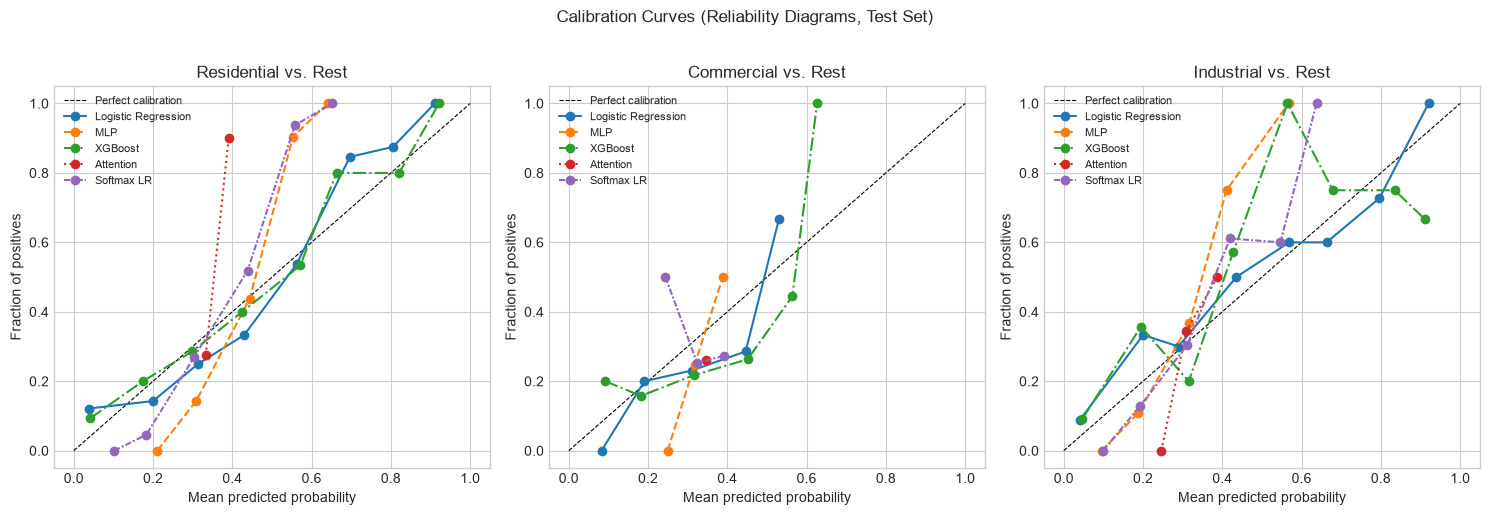

In [7]:
calib_models = [
    ('Logistic Regression', lr_model,      X_test_sc),
    ('MLP',                 mlp_model,     X_test_sc),
    ('XGBoost',             xgb_model,     X_test),
    ('Attention',           attn_model,    X_test_sc),
    ('Softmax LR',          softmax_model, X_test_sc),
]

fig, axes = plt.subplots(1, len(CLASSES), figsize=(15, 5))
line_styles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]
palette = sns.color_palette('tab10', len(calib_models))

for k, (class_name, ax) in enumerate(zip(CLASSES, axes)):
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Perfect calibration')
    for (name, model, X), color, ls in zip(calib_models, palette, line_styles):
        proba = model.predict_proba(X)[:, k]
        try:
            frac_pos, mean_pred = calibration_curve(
                (y_test == k).astype(int), proba, n_bins=8, strategy='uniform'
            )
            ax.plot(mean_pred, frac_pos, marker='o', color=color,
                    linestyle=ls, lw=1.5, label=name)
        except Exception:
            pass
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(f'{class_name} vs. Rest')
    ax.legend(fontsize=8)

plt.suptitle('Calibration Curves (Reliability Diagrams, Test Set)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**Observations:**  
- Logistic regression is typically the best-calibrated classifier by construction.  
- XGBoost and MLP often output overconfident probabilities (curve above diagonal at high probability) — this can be corrected with Platt scaling (`CalibratedClassifierCV(method='sigmoid')`).
- The Attention Classifier's probabilities are by construction normalised attention weights, so calibration depends on the kernel bandwidth.

---
## Summary

| Diagnostic | Key finding |
|---|---|
| Learning curves | Both train and CV accuracy plateau relatively early — data quantity is not the bottleneck |
| ROC / AUC | Weakest class reveals where targeted feature engineering would have the highest ROI |
| Permutation importance | Confirms EDA: Energy Consumption and Square Footage carry most predictive signal |
| Calibration | Logistic regression is best calibrated; XGBoost/MLP may benefit from post-hoc calibration |

**Next step:** Apply `CalibratedClassifierCV` to XGBoost and MLP if predicted probabilities
are needed downstream (e.g. for decision thresholding or expected-value calculations).